# 01. DUT Anti-UAV 데이터 분석
1. train / val / test 파일 수
2. XML 라벨 구조
3. 실제 이미지와 bbox 확인
4. bbox 크기 통계
5. 작은 객체 비율
6. 640 입력 시 예상 bbox 크기
7. 밝기 / 대비


## 1. 라이브러리와 데이터 경로

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import cv2
import pandas as pd
import matplotlib.pyplot as plt

# notebooks 폴더에서 실행하므로 ../data/raw 사용
DATA_ROOT = Path('../data/raw')

print(DATA_ROOT.resolve())


/home/sswwd/projects/small-drone-detection/data/raw


## 2. train / val / test 파일 수 확인

In [2]:
for split in ['train', 'val', 'test']:
    path = DATA_ROOT / split

    images = list(path.rglob('*.jpg'))
    xmls = list(path.rglob('*.xml'))

    print(f'{split:5} | images: {len(images):5} | xml: {len(xmls):5}')


train | images:  5200 | xml:  5200
val   | images:  2600 | xml:  2600
test  | images:  2200 | xml:  2200


## 3. XML 라벨 하나 확인

In [7]:
train_xmls = sorted((DATA_ROOT / 'train').rglob('*.xml'))

sample_xml = train_xmls[0]
print(sample_xml)
print()
print(sample_xml.read_text(encoding='utf-8'))


../data/raw/train/train/xml/00001.xml

<annotation>
	<folder>train</folder>
	<filename>00001.jpg</filename>
	<path>./train/00001.jpg</path>
	<source>
		<database>DUT Anti-UAV Detection</database>
	</source>
	<size>
		<width>550</width>
		<height>412</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>UAV</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>228</xmin>
			<ymin>155</ymin>
			<xmax>353</xmax>
			<ymax>245</ymax>
		</bndbox>
	</object>
</annotation>



## 4. XML에서 bbox 읽기

`xmin, ymin, xmax, ymax`가 Ground Truth bbox입니다.

In [8]:
def read_xml(xml_path):
    root = ET.parse(xml_path).getroot()

    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    boxes = []

    for obj in root.findall('object'):
        box = obj.find('bndbox')

        xmin = int(float(box.find('xmin').text))
        ymin = int(float(box.find('ymin').text))
        xmax = int(float(box.find('xmax').text))
        ymax = int(float(box.find('ymax').text))

        boxes.append([xmin, ymin, xmax, ymax])

    return width, height, boxes


width, height, boxes = read_xml(sample_xml)
print('이미지 크기:', width, 'x', height)
print('bbox:', boxes)


이미지 크기: 550 x 412
bbox: [[228, 155, 353, 245]]


## 5. 실제 이미지에 Ground Truth bbox 그려보기

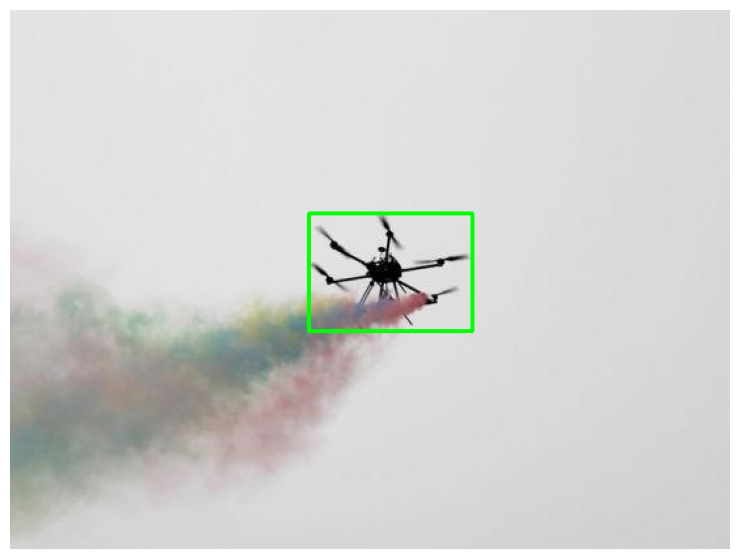

In [9]:
# XML과 같은 이름의 jpg 찾기
image_name = sample_xml.stem + '.jpg'
sample_image = list((DATA_ROOT / 'train').rglob(image_name))[0]

image = cv2.imread(str(sample_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

_, _, boxes = read_xml(sample_xml)

for xmin, ymin, xmax, ymax in boxes:
    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis('off')
plt.show()


## 6. 전체 bbox 정보를 표로 만들기

나중에 작은 객체 비율과 split별 차이를 확인하기 위한 표

In [ ]:
rows = []

for split in ['train', 'val', 'test']:
    xmls = sorted((DATA_ROOT / split).rglob('*.xml'))

    for xml_path in xmls:
        width, height, boxes = read_xml(xml_path)

        for xmin, ymin, xmax, ymax in boxes:
            bbox_w = xmax - xmin
            bbox_h = ymax - ymin
            bbox_ratio = (bbox_w * bbox_h) / (width * height)

            rows.append({
                'split': split,
                'image_width': width,
                'image_height': height,
                'bbox_width': bbox_w,
                'bbox_height': bbox_h,
                'bbox_ratio': bbox_ratio #전체 이미지 면적에서 bbox가 차지하는 비율
            })

df = pd.DataFrame(rows)

SAVE_DIR = Path("../results/data_analysis")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(SAVE_DIR / "bbox_stats.csv", index=False)

df.head()


,split,image_width,image_height,bbox_width,bbox_height,bbox_ratio
0,train,550,412,125,90,0.049647
1,train,1000,667,493,384,0.283826
2,train,511,317,317,204,0.399217
3,train,479,261,276,166,0.366472
4,train,579,388,340,197,0.298150


## 7. bbox 크기와 작은 객체 비율 확인

In [21]:
# split 순서
split_order = ['train', 'val', 'test']

# 필요한 통계 계산
stats = []

for split in split_order:
    temp = df[df['split'] == split]

    stats.append({
        'split': split,
        '객체 수': len(temp),
        'bbox width 중앙값': temp['bbox_width'].median(),
        'bbox height 중앙값': temp['bbox_height'].median(),
        'bbox 면적 중앙값(%)': temp['bbox_ratio'].median() * 100,
        '1% 미만 객체(%)': (temp['bbox_ratio'] < 0.01).mean() * 100,
        '5% 미만 객체(%)': (temp['bbox_ratio'] < 0.05).mean() * 100
    })

stats_df = pd.DataFrame(stats)

stats_df

,split,객체 수,bbox width 중앙값,bbox height 중앙값,bbox 면적 중앙값(%),1% 미만 객체(%),5% 미만 객체(%)
0,train,5243,43.0,23.0,0.047201,88.327294,94.831204
1,val,2621,42.0,23.0,0.045910,88.553987,94.238840
2,test,2245,55.0,30.0,0.091146,75.857461,92.828508


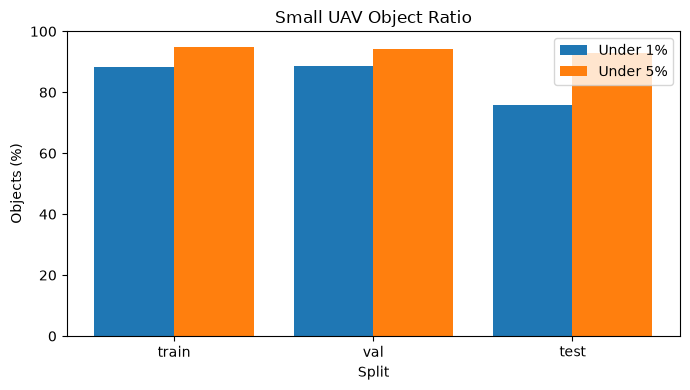

In [20]:
plt.figure(figsize=(7, 4))

x = range(len(stats_df))

plt.bar(
    [i - 0.2 for i in x],
    stats_df['1% 미만 객체(%)'],
    width=0.4,
    label='Under 1%'
)

plt.bar(
    [i + 0.2 for i in x],
    stats_df['5% 미만 객체(%)'],
    width=0.4,
    label='Under 5%'
)

plt.xticks(x, stats_df['split'])

plt.title('Small UAV Object Ratio')
plt.xlabel('Split')
plt.ylabel('Objects (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

bbox 크기: 1181 x 392 px
bbox 면적 비율: 50.2335 %


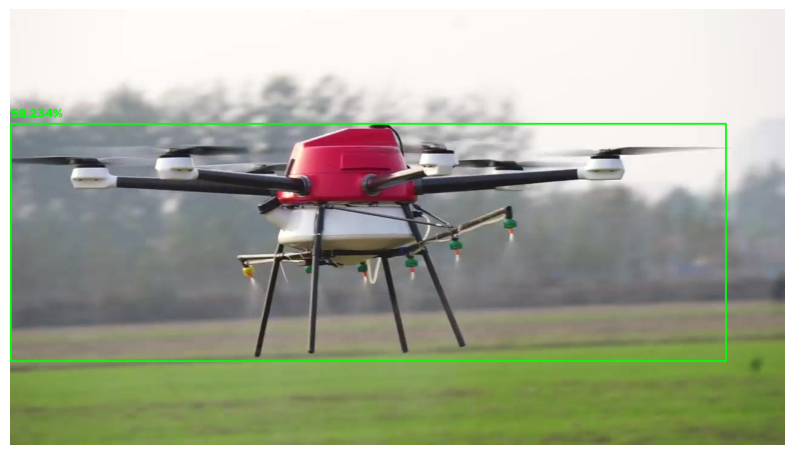

In [24]:
# 샘플 이미지 확인
# 직접 확인할 이미지와 XML 경로
image_path = "../data/raw/train/train/img/00371.jpg"
xml_path = "../data/raw/train/train/xml/00371.xml"

# 이미지 읽기
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# XML에서 이미지 크기와 bbox 읽기
width, height, boxes = read_xml(xml_path)

# 이미지 전체 면적
image_area = width * height

for xmin, ymin, xmax, ymax in boxes:

    # bbox 크기
    bbox_width = xmax - xmin
    bbox_height = ymax - ymin
    bbox_area = bbox_width * bbox_height

    # 이미지 전체에서 bbox가 차지하는 비율
    bbox_ratio = bbox_area / image_area * 100

    # bbox 그리기
    cv2.rectangle(
        image,
        (xmin, ymin),
        (xmax, ymax),
        (0, 255, 0),
        2
    )

    # bbox 위에 비율 표시
    text = f"{bbox_ratio:.3f}%"

    cv2.putText(
        image,
        text,
        (xmin, max(ymin - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    print("bbox 크기:", bbox_width, "x", bbox_height, "px")
    print("bbox 면적 비율:", round(bbox_ratio, 4), "%")

# 화면 출력
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

## 8. bbox 면적 분포 보기
train + val + test 객체를 합친 bbox 면적 비율 분포

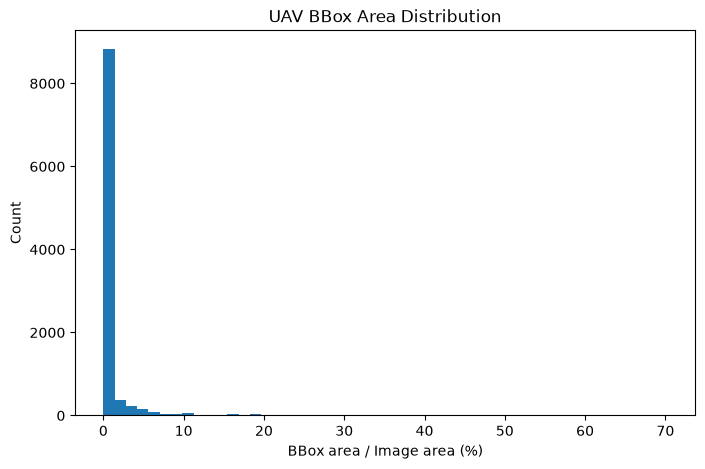

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['bbox_ratio'] * 100, bins=50)
plt.xlabel('BBox area / Image area (%)')
plt.ylabel('Count')
plt.title('UAV BBox Area Distribution')
plt.show()


## 9. 640 입력 시 예상 bbox 크기

원본 이미지의 긴 변을 640으로 줄인다고 가정해 bbox가 어느 정도로 작아지는지 확인합니다.
실제 YOLO letterbox와 완전히 같은 계산은 아니고, 크기 감소 정도를 간단히 보기 위한 값입니다.

In [22]:
scale = 640 / df[['image_width', 'image_height']].max(axis=1)

df['bbox_width_640'] = df['bbox_width'] * scale
df['bbox_height_640'] = df['bbox_height'] * scale

print('640 기준 bbox width 중앙값:', round(df['bbox_width_640'].median(), 2), 'px')
print('640 기준 bbox height 중앙값:', round(df['bbox_height_640'].median(), 2), 'px')

small = (df['bbox_width_640'] < 10) | (df['bbox_height_640'] < 10)
print('한 변이 10px 미만인 객체:', round(small.mean() * 100, 2), '%')


640 기준 bbox width 중앙값: 15.0 px
640 기준 bbox height 중앙값: 8.0 px
한 변이 10px 미만인 객체: 60.95 %


## 10. 이미지 밝기와 대비 확인

- 밝기: grayscale 평균
- 대비: grayscale 표준편차

값 자체보다 train / val / test가 크게 다른지 보는 용도입니다.

In [23]:
rows = []

for split in ['train', 'val', 'test']:
    images = list((DATA_ROOT / split).rglob('*.jpg'))

    for image_path in images:
        gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if gray is None:
            continue

        rows.append({
            'split': split,
            'brightness': gray.mean(),
            'contrast': gray.std()
        })

image_df = pd.DataFrame(rows)
image_df.groupby('split')[['brightness', 'contrast']].mean().round(2)


,brightness,contrast
split,,
test,122.44,57.16
train,116.06,60.94
val,116.08,60.82
